In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_columns', 60)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import os
pd.set_option('display.max_columns', 60)
os.makedirs("../results/figures", exist_ok=True)

Master clean: (1279, 7)
          acc  d2o  length  n_go_exp  cluster  n_dis_regions  total_dis_len
0  A0A090N8E9    0     751         0      312            1.0           17.0
1  A0A0C4DGY3    0     505         0      559            1.0          103.0
2  A0A1B0GTR3    0     108         0     1132            1.0          108.0
3  A0A5F9ZHA1    0    1849         0        4            6.0          147.0
4      A4D126    0     451         8      640            1.0           16.0


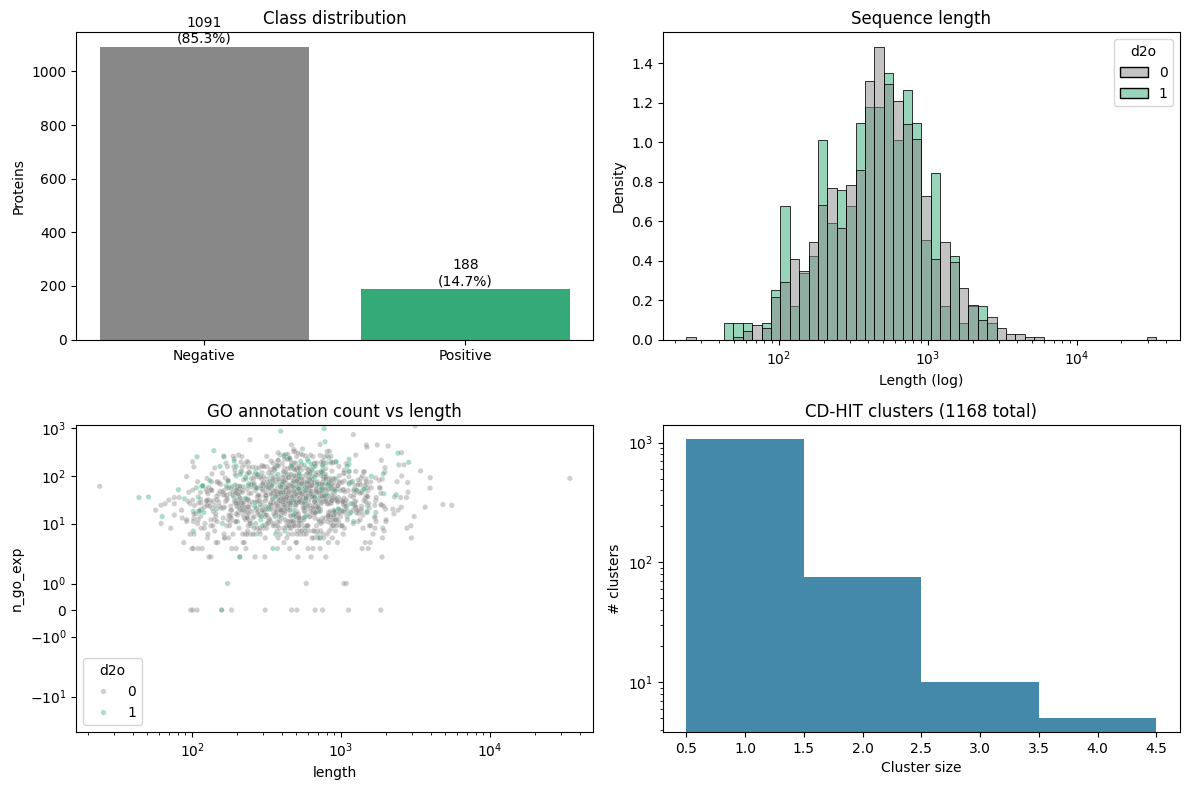

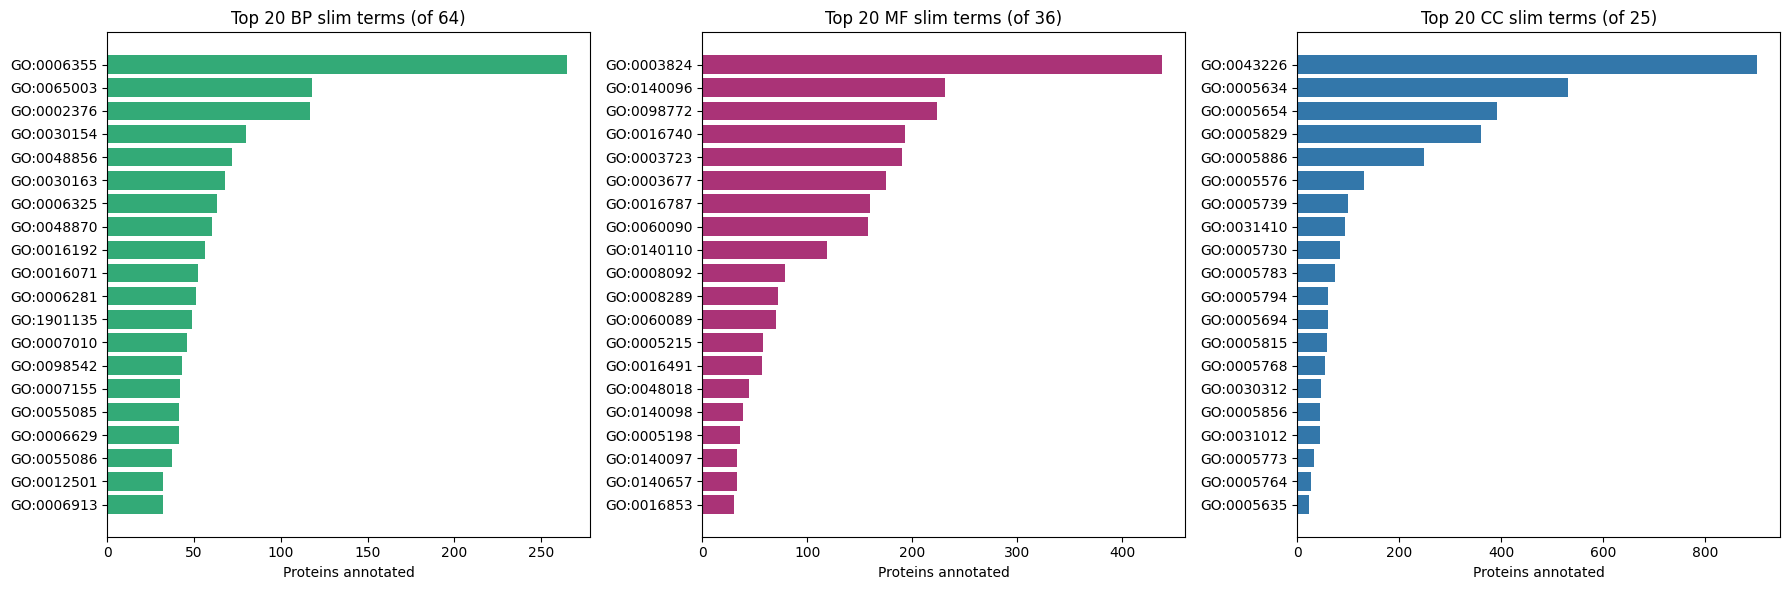

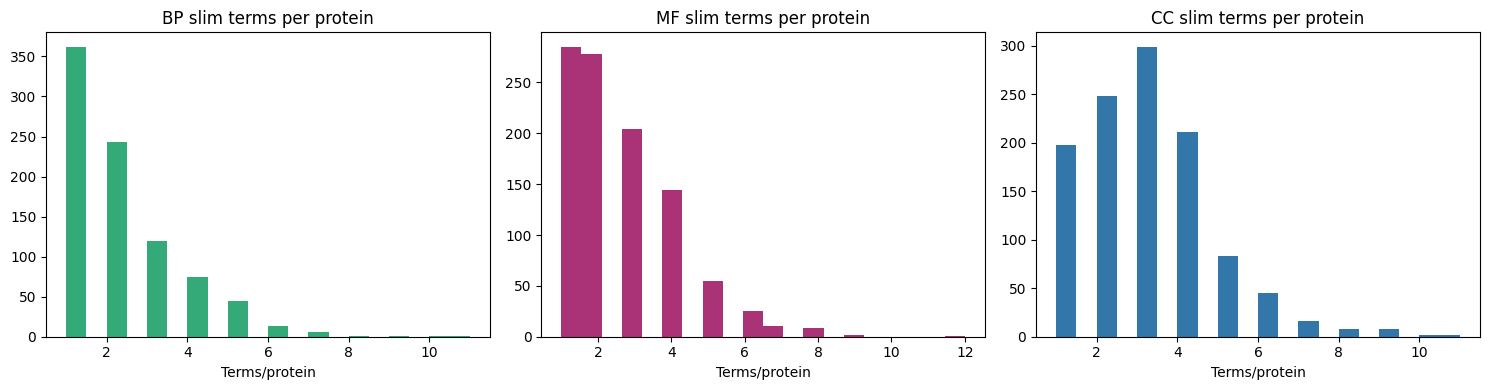

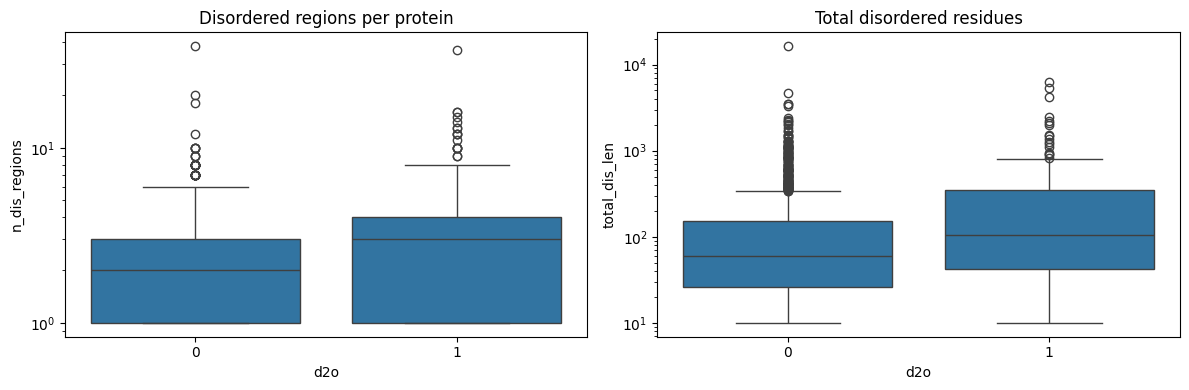


=== Medians by class ===
     length  n_go_exp  n_dis_regions  total_dis_len
d2o                                                
0     484.0      31.0            2.0           60.0
1     475.0      54.5            3.0          104.0

=== Bias ratios (positive median / negative median) ===
length           0.98
n_go_exp         1.76
n_dis_regions    1.50
total_dis_len    1.73
dtype: float64


In [2]:
# ---- Load everything ----
master = (pd.read_csv("../data/labels.csv")
            .merge(pd.read_csv("../data/sequences.csv")[['acc','length']], on='acc', how='left'))

go_exp = pd.read_csv("../data/go_annotations_experimental.csv", low_memory=False)
master = master.merge(go_exp.groupby('DB_Object_ID').size()
                            .rename('n_go_exp').reset_index()
                            .rename(columns={'DB_Object_ID':'acc'}),
                      on='acc', how='left')
master['n_go_exp'] = master['n_go_exp'].fillna(0).astype(int)

clusters = pd.read_csv("../data/clusters.csv")
master = master.merge(clusters, on='acc', how='left')

# DisProt region summaries
disprot = pd.read_csv("../data/disprot.tsv", sep='\t', low_memory=False)
disprot = disprot.rename(columns={'UniProt ACC':'acc','Organism':'organism',
                                  'Term namespace':'term_namespace',
                                  'Start':'start','End':'end'})
disprot['acc'] = disprot['acc'].str.split('-').str[0]
state = disprot[(disprot['organism']=='Homo sapiens') &
                (disprot['term_namespace']=='Structural state')].copy()
state['region_len'] = state['end'] - state['start'] + 1
region_summary = state.groupby('acc').agg(
    n_dis_regions=('start','size'),
    total_dis_len=('region_len','sum')).reset_index()
master = master.merge(region_summary, on='acc', how='left')

master.to_csv("../data/master_clean.csv", index=False)
print(f"Master clean: {master.shape}")
print(master.head())

# ---- Figure 1: 2x2 summary ----
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
counts = master['d2o'].value_counts().sort_index()
ax[0,0].bar(['Negative','Positive'], counts.values, color=['#888','#3a7'])
for i,v in enumerate(counts.values):
    ax[0,0].text(i, v+15, f"{v}\n({100*v/len(master):.1f}%)", ha='center')
ax[0,0].set_title("Class distribution"); ax[0,0].set_ylabel("Proteins")

sns.histplot(data=master, x='length', hue='d2o', bins=50, log_scale=(True,False),
             palette={0:'#888',1:'#3a7'}, ax=ax[0,1], stat='density', common_norm=False)
ax[0,1].set_title("Sequence length"); ax[0,1].set_xlabel("Length (log)")

sns.scatterplot(data=master, x='length', y='n_go_exp', hue='d2o', alpha=0.4, s=15,
                palette={0:'#888',1:'#3a7'}, ax=ax[1,0])
ax[1,0].set_xscale('log'); ax[1,0].set_yscale('symlog')
ax[1,0].set_title("GO annotation count vs length")

cluster_sizes = clusters.groupby('cluster').size()
ax[1,1].hist(cluster_sizes, bins=range(1, cluster_sizes.max()+2),
             align='left', color='#48a')
ax[1,1].set_title(f"CD-HIT clusters ({len(cluster_sizes)} total)")
ax[1,1].set_xlabel("Cluster size"); ax[1,1].set_ylabel("# clusters"); ax[1,1].set_yscale('log')
plt.tight_layout(); plt.savefig("../results/figures/eda_summary.png", dpi=150); plt.show()

# ---- Figure 2: top-20 GO Slim terms per aspect ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#3a7','#a37','#37a']
for i, (name, axn) in enumerate(zip(['BP','MF','CC'], axes)):
    mat = pd.read_csv(f"../data/features_GO_{name}_slim.csv", index_col=0)
    top = mat.sum().sort_values(ascending=False).head(20)
    axn.barh(top.index[::-1], top.values[::-1], color=colors[i])
    axn.set_title(f"Top 20 {name} slim terms (of {mat.shape[1]})")
    axn.set_xlabel("Proteins annotated")
plt.tight_layout(); plt.savefig("../results/figures/eda_go_slim_top20.png", dpi=150); plt.show()

# ---- Figure 3: slim-terms-per-protein ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, axn) in enumerate(zip(['BP','MF','CC'], axes)):
    mat = pd.read_csv(f"../data/features_GO_{name}_slim.csv", index_col=0)
    per_protein = mat.sum(axis=1)
    axn.hist(per_protein, bins=20, color=colors[i])
    axn.set_title(f"{name} slim terms per protein"); axn.set_xlabel("Terms/protein")
plt.tight_layout(); plt.savefig("../results/figures/eda_slim_per_protein.png", dpi=150); plt.show()

# ---- Figure 4: disorder profile by class ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=master, x='d2o', y='n_dis_regions', ax=axes[0])
axes[0].set_title("Disordered regions per protein"); axes[0].set_yscale('log')
sns.boxplot(data=master, x='d2o', y='total_dis_len', ax=axes[1])
axes[1].set_title("Total disordered residues"); axes[1].set_yscale('log')
plt.tight_layout(); plt.savefig("../results/figures/eda_disorder_profile.png", dpi=150); plt.show()

# ---- Summary numbers ----
cols = ['length','n_go_exp','n_dis_regions','total_dis_len']
print("\n=== Medians by class ===")
print(master.groupby('d2o')[cols].median())
print("\n=== Bias ratios (positive median / negative median) ===")
print((master[master['d2o']==1][cols].median() /
       master[master['d2o']==0][cols].median()).round(2))

In [3]:
# === W4.7: Go/no-go criteria check ===
master = pd.read_csv("../data/master_clean.csv")
clusters_df = pd.read_csv("../data/clusters.csv")

results = []

n_pos = int((master['d2o']==1).sum()); n_neg = int((master['d2o']==0).sum())
results.append(("1. N sufficient (≥150 pos & ≥500 neg)",
                n_pos >= 150 and n_neg >= 500,
                f"positives={n_pos}, negatives={n_neg}"))

pos_rate = master['d2o'].mean()
results.append(("2. Positive rate near spike (10–20%)",
                0.10 <= pos_rate <= 0.20,
                f"positive rate={pos_rate:.1%}"))

seq_coverage = 1 - master['length'].isna().mean()
results.append(("3. Sequence coverage ≥95%",
                seq_coverage >= 0.95,
                f"coverage={seq_coverage:.1%}"))

go_coverage = (master['n_go_exp'] > 0).mean()
results.append(("4. ≥70% proteins have ≥1 experimental GO annotation",
                go_coverage >= 0.70,
                f"coverage={go_coverage:.1%}"))

slim_ok = True; slim_info = []
for name in ['BP', 'MF', 'CC']:
    mat = pd.read_csv(f"../data/features_GO_{name}_slim.csv", index_col=0)
    n_cols = mat.shape[1]
    n_useful = int((mat.sum(axis=0) >= 5).sum())
    slim_ok = slim_ok and n_cols >= 20 and n_useful >= 10
    slim_info.append(f"{name}: {n_cols} cols, {n_useful} with ≥5 proteins")
results.append(("5. GO Slim matrices non-degenerate (≥20 cols, ≥10 useful)",
                slim_ok, "; ".join(slim_info)))

pos_clusters = master[master['d2o']==1]['cluster'].dropna().nunique()
results.append(("6. Positives span ≥50 distinct clusters",
                pos_clusters >= 50,
                f"positives spread across {pos_clusters} clusters"))

neg_med = master[master['d2o']==0]['n_go_exp'].median()
pos_med = master[master['d2o']==1]['n_go_exp'].median()
ratio = pos_med / neg_med if neg_med else float('inf')
results.append(("7. Annotation bias median ratio < 4×",
                ratio < 4,
                f"ratio={ratio:.2f}× (positives {pos_med:.0f} / negatives {neg_med:.0f})"))

print("="*72)
print(" GO / NO-GO CRITERIA CHECK")
print("="*72)
for label, passed, detail in results:
    print(f"\n{'✓ PASS' if passed else '✗ FAIL'}  {label}")
    print(f"        {detail}")

all_pass = all(r[1] for r in results)
print("\n" + "="*72)
print(" VERDICT:", "GO — proceed to Week 5" if all_pass else "NO-GO — investigate failed criteria")
print("="*72)

 GO / NO-GO CRITERIA CHECK

✓ PASS  1. N sufficient (≥150 pos & ≥500 neg)
        positives=188, negatives=1091

✓ PASS  2. Positive rate near spike (10–20%)
        positive rate=14.7%

✓ PASS  3. Sequence coverage ≥95%
        coverage=100.0%

✓ PASS  4. ≥70% proteins have ≥1 experimental GO annotation
        coverage=99.0%

✓ PASS  5. GO Slim matrices non-degenerate (≥20 cols, ≥10 useful)
        BP: 64 cols, 54 with ≥5 proteins; MF: 36 cols, 31 with ≥5 proteins; CC: 25 cols, 25 with ≥5 proteins

✓ PASS  6. Positives span ≥50 distinct clusters
        positives spread across 182 clusters

✓ PASS  7. Annotation bias median ratio < 4×
        ratio=1.76× (positives 54 / negatives 31)

 VERDICT: GO — proceed to Week 5
